<a href="https://colab.research.google.com/github/sumin-hwang/Do_It_Deeplearning/blob/main/matplot_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## cmd + enter : 실행하기

In [ ]:
print('test')

test


In [ ]:
import numpy as np
print(np.__version__)

my_arr = np.array([[10, 20, 30], [40, 50, 60]])
print(my_arr, type(my_arr))

2.1.3
[[10 20 30]
 [40 50 60]] <class 'numpy.ndarray'>


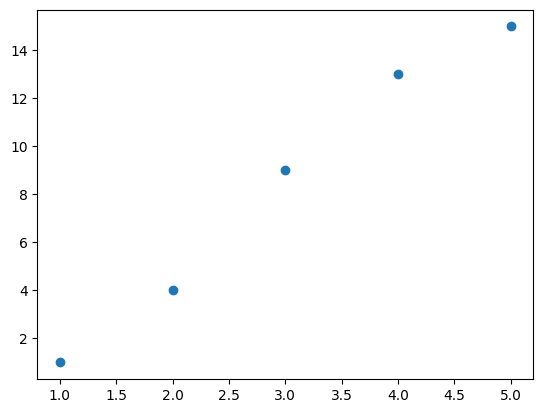

In [ ]:
import matplotlib.pyplot as plt

plt.scatter([1,2,3,4,5], [1,4,9,13,15])
plt.show()

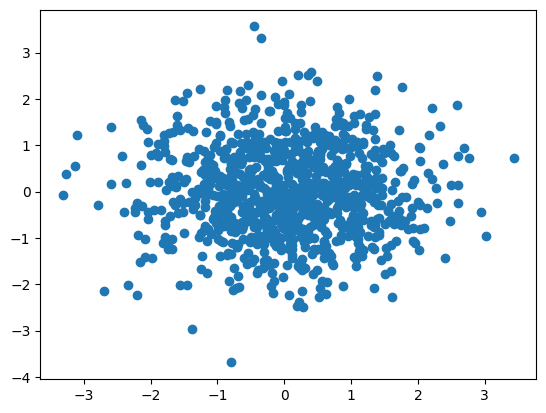

In [ ]:
import matplotlib.pyplot as plt

x = np.random.randn(1000)
y = np.random.randn(1000)

plt.scatter(x, y)
plt.show()

# 선형회귀


- 선형회귀 : 새 입력에 대해 어떤 값을 예상하는 것
- 열 : 샘플의 특성, 행 : 샘플
- 우리는 입력 데이터와 타깃데이터의 수치만 보고 둘 사이의 규칙을 찾으면 된다.
- 입력 데이터와 타깃데이터를 통해 기울기와 절편을 찾는 것

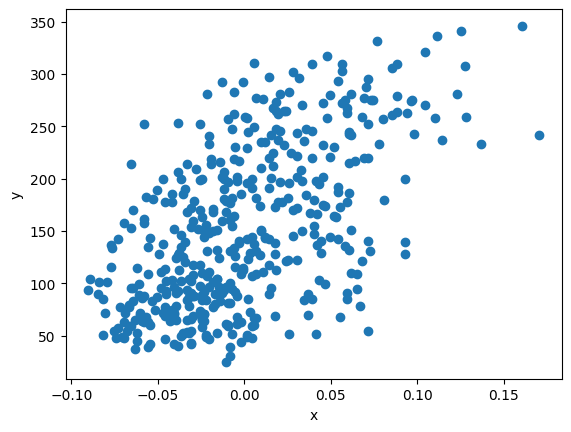

In [ ]:
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()

import matplotlib.pyplot as plt

plt.scatter(diabetes.data[:, 2], diabetes.target)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [ ]:
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()

# 크기확인
# print(diabetes.data.shape, diabetes.target.shape)

# 데이터 출력
diabetes.data[0:3]
diabetes.target[:3]

array([151.,  75., 141.])

# 경사하강법

- 특성의 개수를 1,2 개만 사용하여 2차원이나 3차원의 그래프로 그리는 경우가 많음.
- 모델이 데이터를 잘 표현할 수 있도록 기울기를 사용하여 모델을 조금씩 조정하는 최적화 알고리즘

In [5]:
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()

w = 1.0
b = 1.0
x = diabetes.data[:2]
y = diabetes.target

y_hat = x[0]* w + b
# print(y_hat)

# print(y[0]) # 타겟값

w_inc = w + 0.1
y_hat_inc = x[0] * w_inc + b
print(y_hat_inc)

[1.0418835  1.05574813 1.06786583 1.02405962 0.95135415 0.96169716
 0.95225907 0.99714851 1.02189823 0.98058926]


손실함수
- 제곱오차는 타겟값과 예측값을 뺀 다음 제곱한 것, 제곱오차가 최소가 되면 산점도 그래프를 가장 잘 표현한 직선이 그려짐


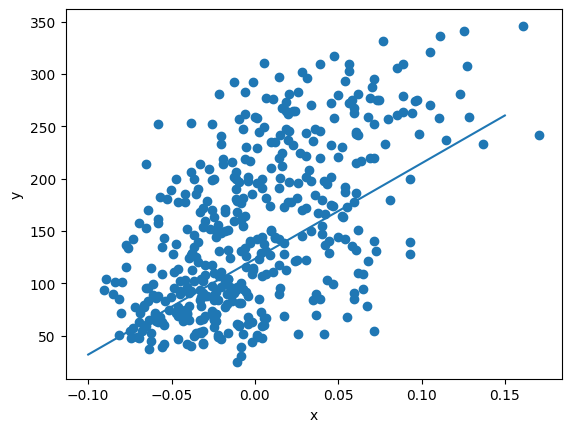

In [9]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes

# Ensure diabetes dataset is loaded
diabetes = load_diabetes()

class Neuron:
  def __init__(self):
    self.w = 1.0
    self.b = 1.0

  def forpass(self, x):
    y_hat = x * self.w + self.b # 직선 방정식을 계산함
    return y_hat

  def backprop(self, x, err):
    w_grad = x * err # 가중치에 대한 그레이디언트
    b_grad = 1 * err # 절편에 대한 그레이디언트
    return w_grad, b_grad

  def fit(self, x, y, epochs = 100):
    for i in range(epochs):
      for x_i, y_i in zip (x, y): # 모든 샘플에 대해 반복함
        y_hat = self.forpass(x_i) # 정방향 계산
        err = - (y_i - y_hat) # 오차 계산
        w_grad, b_grad = self.backprop(x_i, err) # 역방향 계싼
        self.w -= w_grad # 가중치 업데이트
        self.b -= b_grad # 절편 업데이트

# Correctly define x and y for single feature regression and plotting
x = diabetes.data[:, 2] # Use the third feature as the input 'x'
y = diabetes.target    # Use the target values as 'y'

neuron = Neuron()
neuron.fit(x, y)

plt.scatter(x, y)
pt1 = (-0.1, -0.1 * neuron.w + neuron.b)
pt2 = (0.15, 0.15 * neuron.w + neuron.b)
plt.plot([pt1[0], pt2[0]], [pt1[1], pt2[1]])
plt.xlabel('x')
plt.ylabel('y')
plt.show()